# Local and full spectral functions

For very large systems, exact diagonalization becomes impractical. Passing `mode="KPM"` to
`h.get_dos()` switches to a stochastic Chebyshev kernel polynomial expansion, which never builds
the full spectrum: it estimates the trace of a spectral function through a random-vector stochastic
trace, expanded in Chebyshev polynomials of the (rescaled) Hamiltonian. The same machinery gives
the **local** DOS at a single site by seeding the expansion with a delta vector at that site instead
of a random vector -- `h.get_ldos(mode="KPM")` -- letting the full and local spectral function be
compared directly on a large sparse system.

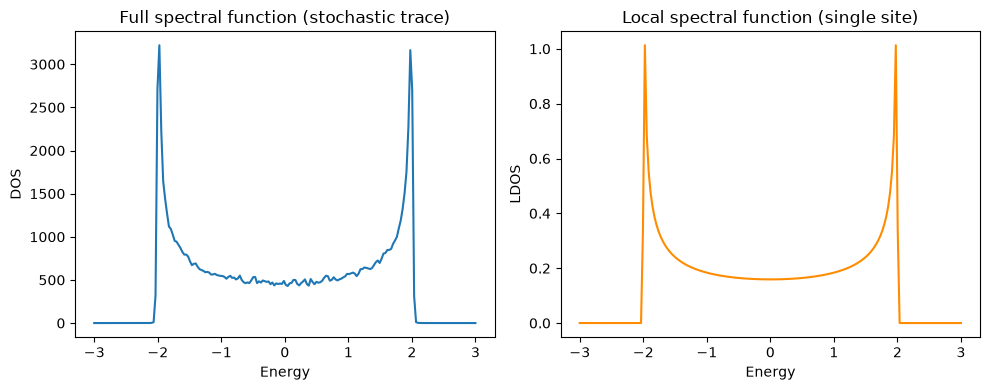

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula.ldos import dos_site

g = geometry.chain()
g = g.get_supercell(3000) # a big supercell
g.dimensionality = 0
h = g.get_hamiltonian(is_sparse=True,has_spin=False)

energies = np.linspace(-3.0,3.0,200)
x,y_full = h.get_dos(mode="KPM",energies=energies,delta=1e-2,ntries=10)
x,y_local = dos_site(h,i=1500,mode="KPM",energies=energies,delta=1e-2)

fig,axs = plt.subplots(1,2,figsize=(10,4))
axs[0].plot(x,y_full)
axs[0].set_xlabel("Energy") ; axs[0].set_ylabel("DOS")
axs[0].set_title("Full spectral function (stochastic trace)")
axs[1].plot(x,y_local,c="darkorange")
axs[1].set_xlabel("Energy") ; axs[1].set_ylabel("LDOS")
axs[1].set_title("Local spectral function (single site)")
plt.tight_layout()
plt.show()